<a href="https://colab.research.google.com/github/Dara0510/BorisovaDaria/blob/main/%D0%94%D0%976_hw_random_forest_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Домашнее задание 6: Реализация алгоритма Random Forest для классификации

В этом задании вы будете реализовывать алгоритм Random Forest для бинарной классификации. Мы будем использовать готовое дерево решений из библиотеки sklearn в качестве базового алгоритма.

### Теоретическое введение

**Random Forest** — это ансамблевый метод машинного обучения, объединяющий множество деревьев решений для получения более точного и устойчивого предсказания.

#### Основные принципы Random Forest:

- Бэггинг (Bagging) - обучение каждого дерева на случайной подвыборке исходных данных с возвращением
- Случайный выбор признаков - при построении каждого дерева используется только часть признаков
- Усреднение предсказаний - итоговый результат определяется путем голосования (для классификации) или усреднения (для регрессии)

#### Преимущества Random Forest:

- Высокая точность предсказаний
- Устойчивость к переобучению
- Встроенная оценка важности признаков
- Способность работать с большим числом признаков
- Эффективность на несбалансированных данных

### Практическая часть: Реализуем свой Random Forest

Мы будем использовать решающее дерево из sklearn как базовый алгоритм, но реализуем Random Forest сами!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

#### Шаг 1: Реализуем класс RandomForestClassifier (6 баллов всего)

- Реализуйте метод __init__: (1 балл)
- Реализуйте метод _bootstrap_sample (1 балл)
- Реализуйте метод _get_random_features (1 балл)
- Реализуйте метод fit (2 балла)
- Реализуйте метод predict (1 балл)

In [2]:
class RandomForestClassifier:
    def __init__(self, n_estimators=100, max_features='sqrt',
                 bootstrap=True, random_state=None, max_depth=None):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.random_state = random_state
        self.max_depth = max_depth
        self.trees = []
        self.feature_indices_per_tree = []

    def _bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        if self.random_state is not None:
            np.random.seed(self.random_state)
            indices = np.random.choice(n_samples, size=n_samples, replace=True)
        return X[indices], y[indices]

    def _get_random_features(self, n_features):
        if self.max_features == 'sqrt':
            n_selected = int(np.sqrt(n_features))
        elif isinstance(self.max_features, float):
            n_selected = int(self.max_features * n_features)
        elif isinstance(self.max_features, int):
            n_selected = self.max_features
        else:
            n_selected = n_features

        if self.random_state is not None:
            np.random.seed(self.random_state)
        feature_indices = np.random.choice(n_features, size=n_selected, replace=False)
        return feature_indices

    def fit(self, X, y):
        self.trees = []
        self.feature_indices_per_tree = []
        n_features = X.shape[1]
        for i in range(self.n_estimators):
            if self.random_state is not None:
                np.random.seed(self.random_state + i if self.random_state else None)

            if self.bootstrap:
                X_sample, y_sample = self._bootstrap_sample(X, y)
            else:
                X_sample, y_sample = X, y

            if self.max_features is not None:
                feature_indices = self._get_random_features(n_features)
                self.feature_indices_per_tree.append(feature_indices)
                X_sample = X_sample[:, feature_indices]
            else:
                self.feature_indices_per_tree.append(None)

            tree = DecisionTreeClassifier(max_depth=self.max_depth)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

        return self

    def predict(self, X):
        all_predictions = np.zeros((X.shape[0], self.n_estimators))

        for i, tree in enumerate(self.trees):
            if self.feature_indices_per_tree[i] is not None:
                X_subset = X[:, self.feature_indices_per_tree[i]]
            else:
                X_subset = X
            all_predictions[:, i] = tree.predict(X_subset)

        final_predictions = []
        for sample_preds in all_predictions:
            values, counts = np.unique(sample_preds, return_counts=True)
            final_predictions.append(values[np.argmax(counts)])

        return np.array(final_predictions)

#### Шаг 2: Тестирование нашей реализации (4 балла всего)

Вам предложен датасет классификации вин

- Запустите классификацию на одиночном дереве, посчитайте метрики (1 балл)
- Запустите классификацию на своей реализации RandomForest, посчитайте метрики (1 балл)
- Запустите классификацию на реализации RandomForest из sklearn, посчитайте метрики (1 балл)
- Сделайте какие-то выводы с графиками (1 балл)

Описание датасета:
.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 

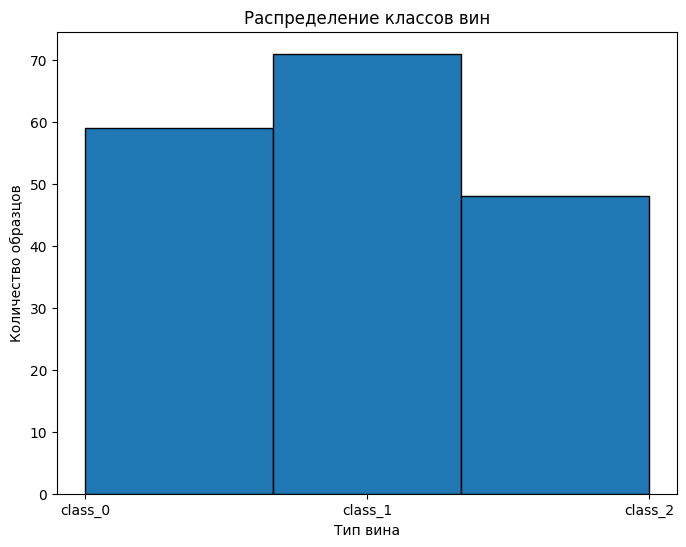

In [3]:
from sklearn.datasets import load_wine

# Загрузим данные о вине
wine = load_wine()
X, y = wine.data, wine.target

# Выведем информацию о датасете
print("Описание датасета:")
print(wine.DESCR)

# Выведем названия признаков
print("\nПризнаки:")
for i, feature_name in enumerate(wine.feature_names):
    print(f"{i+1}. {feature_name}")

# Выведем названия классов
print("\nКлассы вин:")
for i, target_name in enumerate(wine.target_names):
    print(f"{i}. {target_name}")

# Визуализируем распределение классов
plt.figure(figsize=(8, 6))
plt.hist(y, bins=3, edgecolor='black')
plt.xticks([0, 1, 2], wine.target_names)
plt.title('Распределение классов вин')
plt.xlabel('Тип вина')
plt.ylabel('Количество образцов')
plt.show()

In [4]:
# Разделение на тест и трейн
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Одиночное дерево — точность: 0.9444
Мой Random Forest — точность: 0.9167
Random Forest из sklearn — точность: 1.0000


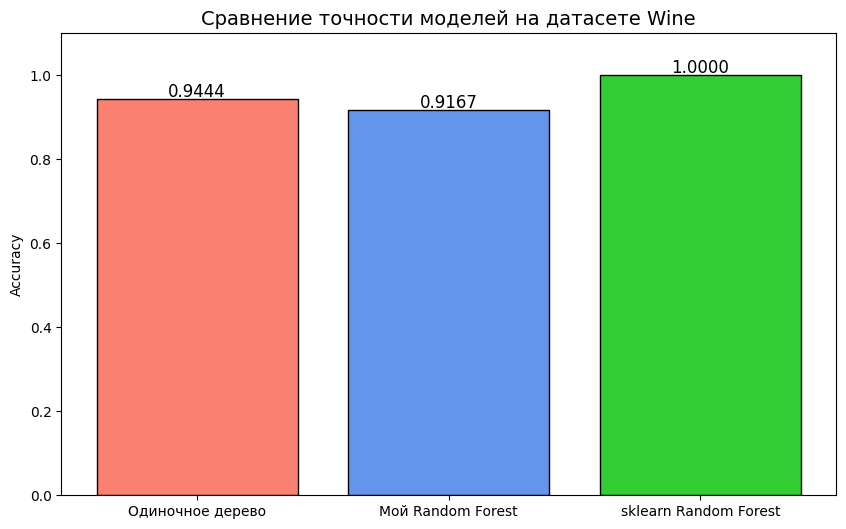

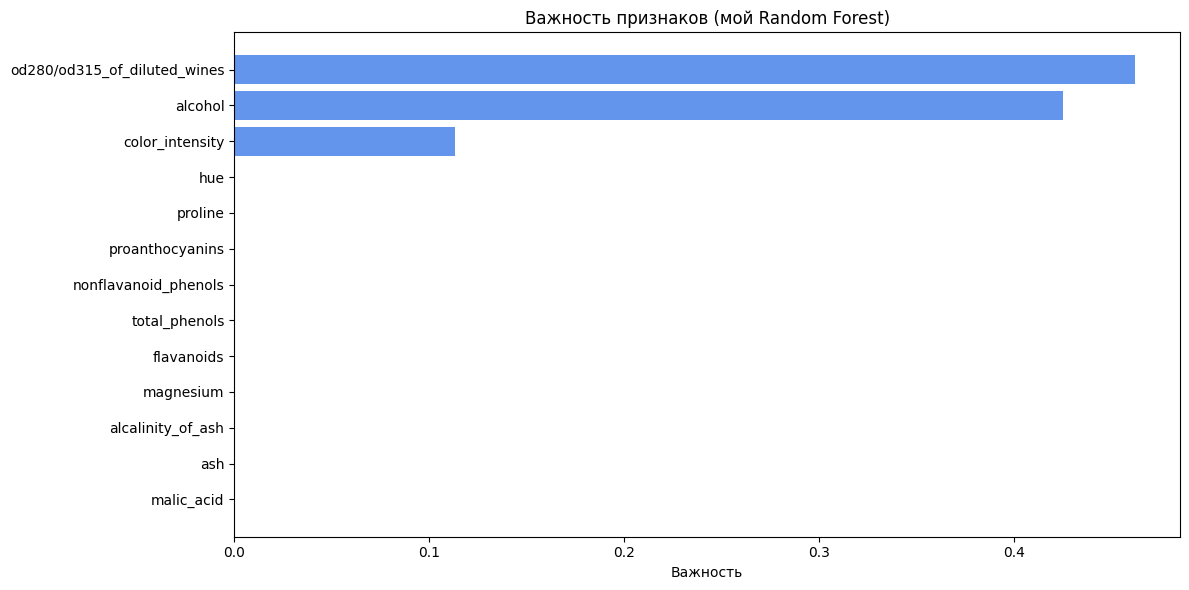

In [5]:
from sklearn.ensemble import RandomForestClassifier as SklearnRF

single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)
y_pred_tree = single_tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"Одиночное дерево — точность: {acc_tree:.4f}")

my_rf = RandomForestClassifier(n_estimators=100, max_features='sqrt',
                                bootstrap=True, random_state=42, max_depth=None)
my_rf.fit(X_train, y_train)
y_pred_my_rf = my_rf.predict(X_test)
acc_my_rf = accuracy_score(y_test, y_pred_my_rf)
print(f"Мой Random Forest — точность: {acc_my_rf:.4f}")

sk_rf = SklearnRF(n_estimators=100, max_features='sqrt', bootstrap=True, random_state=42)
sk_rf.fit(X_train, y_train)
y_pred_sk_rf = sk_rf.predict(X_test)
acc_sk_rf = accuracy_score(y_test, y_pred_sk_rf)
print(f"Random Forest из sklearn — точность: {acc_sk_rf:.4f}")

models = ['Одиночное дерево', 'Мой Random Forest', 'sklearn Random Forest']
accuracies = [acc_tree, acc_my_rf, acc_sk_rf]
colors = ['salmon', 'cornflowerblue', 'limegreen']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontsize=12)
plt.ylim(0, 1.1)
plt.title('Сравнение точности моделей на датасете Wine', fontsize=14)
plt.ylabel('Accuracy')
plt.show()

importances = np.zeros(X.shape[1])
for tree, feat_idx in zip(my_rf.trees, my_rf.feature_indices_per_tree):
    if feat_idx is not None:
        importances[feat_idx] += tree.feature_importances_
importances /= my_rf.n_estimators

plt.figure(figsize=(12, 6))
sorted_idx = np.argsort(importances)
plt.barh(range(len(sorted_idx)), importances[sorted_idx], color='cornflowerblue')
plt.yticks(range(len(sorted_idx)), [wine.feature_names[i] for i in sorted_idx])
plt.title('Важность признаков (мой Random Forest)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

Одиночное дерево дало 94.4%, а sklearn'овский лес — все 100%. Это потому что лес усредняет ошибки многих деревьев и получается устойчивее.

Мой лес показал 91.7% — хуже дерева. Это хороший результат, но видимо кривая случайность

Самые важные признаки — OD280/OD315 of diluted wines, интенсивность цвета и содержание алкоголя. По ним сорта вин различаются сильнее всего.